# [직장인과 문과생을 위한 수학교실 4기] 22. 미분계산 연습과 나의 감상 나누기-09강 4기 22강

In [1]:
import numpy as np
import sympy as sp
import matplotlib.pyplot as plt

x, h = sp.symbols("x h", real=True)

## 1. 세트 A — 다항·기본함수 미분 (전체 한 바퀴)
세트 A에서 주고받은 형태들을 SymPy 로 직접 미분해 강의의 결과와 맞춰 봅니다.
$\frac{d}{dx}x^n=nx^{n-1}$, $(\sin x)'=\cos x$, $(\ln|x|)'=\tfrac1x$, $(\tan x)'=\sec^2 x$,
$(2^{3x})'=3\cdot 2^{3x}\ln 2$ 등.

In [2]:
set_A = [
    sp.tan(x),
    x**-4,
    sp.sqrt(x),
    x**-2,
    sp.sin(x),
    sp.log(sp.Abs(x)),
    2**(3*x),
    x**3 - 4*x + 1,
    sp.sin(x) + sp.cos(x),
    sp.Integer(7),
]
for f in set_A:
    print(f"d/dx [ {str(f):>14} ] = {sp.simplify(sp.diff(f, x))}")

d/dx [         tan(x) ] = cos(x)**(-2)
d/dx [        x**(-4) ] = -4/x**5
d/dx [        sqrt(x) ] = 1/(2*sqrt(x))
d/dx [        x**(-2) ] = -2/x**3
d/dx [         sin(x) ] = cos(x)
d/dx [    log(Abs(x)) ] = Piecewise((0, Eq(x, 0)), (1/x, True))
d/dx [       2**(3*x) ] = 3*8**x*log(2)
d/dx [ x**3 - 4*x + 1 ] = 3*x**2 - 4
d/dx [ sin(x) + cos(x) ] = -sin(x) + cos(x)
d/dx [              7 ] = 0


흔한 함정 하나: $\sqrt{x}=x^{1/2}$ 로 두어야 $\tfrac12 x^{-1/2}$ 가 나옵니다.
$\sqrt{x}=x^{-1}$ 로 잘못 보면 $-x^{-2}$ 같은 엉뚱한 답이 됩니다.

In [3]:
print("sqrt(x) as x**(1/2) ->", sp.diff(x**sp.Rational(1, 2), x))
print("WRONG x**(-1)       ->", sp.diff(x**-1, x))

sqrt(x) as x**(1/2) -> 1/(2*sqrt(x))
WRONG x**(-1)       -> -1/x**2


## 3. 세트 B — 곱의 미분법 (전체 한 바퀴)
$(uv)' = u'v + uv'$ 를 SymPy 의 자동 미분과 손으로 적은 곱의 미분법으로 양쪽에서 확인합니다.
두 항 어느 쪽도 빠뜨리지 않는 것이 요점입니다.

In [4]:
pairs = [
    (sp.sqrt(x), sp.exp(x)),
    (x**2, sp.log(sp.Abs(x))),
    (x, sp.cos(x)),
    (sp.log(x), 2**x),
    (x**3, sp.log(x)),
    (x, sp.log(x)),
    (x**2, sp.sin(x)),
    (sp.sin(x), sp.cos(x)),
]
for u, v in pairs:
    product_rule = sp.diff(u, x) * v + u * sp.diff(v, x)
    auto = sp.diff(u * v, x)
    ok = sp.simplify(product_rule - auto) == 0
    print(f"({u})*({v}):  u'v+uv' = {sp.simplify(product_rule)}   match={ok}")

(sqrt(x))*(exp(x)):  u'v+uv' = (x + 1/2)*exp(x)/sqrt(x)   match=True
(x**2)*(log(Abs(x))):  u'v+uv' = x*(2*log(Abs(x)) + 1)   match=True
(x)*(cos(x)):  u'v+uv' = -x*sin(x) + cos(x)   match=True
(log(x))*(2**x):  u'v+uv' = 2**x*(x*log(2)*log(x) + 1)/x   match=True
(x**3)*(log(x)):  u'v+uv' = x**2*(3*log(x) + 1)   match=True
(x)*(log(x)):  u'v+uv' = log(x) + 1   match=True
(x**2)*(sin(x)):  u'v+uv' = x*(x*cos(x) + 2*sin(x))   match=True
(sin(x))*(cos(x)):  u'v+uv' = cos(2*x)   match=True


강의에서 짚은 슬립 두 개: $\sqrt{x}\,e^x$ 의 앞 항 계수는 $1$ 이 아니라 $\tfrac12$,
$x^3\ln x$ 의 첫 항은 $2x^2$ 가 아니라 $3x^2$ 입니다. 자동 미분으로 정답을 재확인합니다.

In [5]:
print("d/dx sqrt(x) e^x =", sp.diff(sp.sqrt(x) * sp.exp(x), x))
print("d/dx x^3 ln x    =", sp.simplify(sp.diff(x**3 * sp.log(x), x)))

d/dx sqrt(x) e^x = sqrt(x)*exp(x) + exp(x)/(2*sqrt(x))
d/dx x^3 ln x    = x**2*(3*log(x) + 1)


## 5. 세트 C — 연쇄법칙 (전체 한 바퀴)
$(g\circ f)'(x) = g'(f(x))\,f'(x)$. 바깥을 미분하고 안쪽의 미분을 곱합니다.
$\ln(\ln x)$ 의 정의역 $x>1$, $\ln(\cos x)$ 의 $\cos x>0$ 같은 제약도 함께 떠올립니다.

In [6]:
set_C = [
    sp.exp(sp.sin(x)),
    sp.exp(sp.log(x)),
    sp.cos(4*x),
    sp.sin(2*x + 1),
    sp.log(5*x - 7),
    sp.log(x**2),
    sp.log(sp.cos(x)),
    sp.sin(x**2),
    sp.tan(3*x),
    2**sp.sin(x),
    sp.log(sp.log(x)),
    2**(3*x + 2),
    sp.log(x**2 + 1),
    sp.tan(sp.log(x)),
]
for f in set_C:
    print(f"d/dx [ {str(f):>14} ] = {sp.simplify(sp.diff(f, x))}")

d/dx [    exp(sin(x)) ] = exp(sin(x))*cos(x)
d/dx [              x ] = 1
d/dx [       cos(4*x) ] = -4*sin(4*x)


d/dx [   sin(2*x + 1) ] = 2*cos(2*x + 1)
d/dx [   log(5*x - 7) ] = 5/(5*x - 7)
d/dx [      log(x**2) ] = 2/x
d/dx [    log(cos(x)) ] = -tan(x)
d/dx [      sin(x**2) ] = 2*x*cos(x**2)


d/dx [       tan(3*x) ] = 3/cos(3*x)**2
d/dx [      2**sin(x) ] = 2**sin(x)*log(2)*cos(x)
d/dx [    log(log(x)) ] = 1/(x*log(x))
d/dx [   2**(3*x + 2) ] = 12*2**(3*x)*log(2)
d/dx [  log(x**2 + 1) ] = 2*x/(x**2 + 1)
d/dx [    tan(log(x)) ] = 1/(x*cos(log(x))**2)


$e^{\ln x}=x$ 이므로 그 미분은 $1$, $\ln(x^2+1)$ 은 $\dfrac{2x}{x^2+1}$ ($2^{x^2+1}\cdot 2x$ 가 아님).
연쇄법칙으로 한 단계씩 분해해 봅니다: 바깥 미분 $\times$ 안쪽 미분.

In [7]:
g, f_inner = sp.Function("g"), 5*x + 1
inner = 5*x + 1
print("d/dx ln(5x+1): outer 1/(5x+1) * inner' 5 =", sp.diff(sp.log(inner), x))
print("d/dx (1+sin x)^7: 7(1+sin x)^6 * cos x   =", sp.diff((1 + sp.sin(x))**7, x))

d/dx ln(5x+1): outer 1/(5x+1) * inner' 5 = 5/(5*x + 1)
d/dx (1+sin x)^7: 7(1+sin x)^6 * cos x   = 7*(sin(x) + 1)**6*cos(x)


## 6. "왜 그렇게 되는가" — 정의로 돌아가기
외워 쓰던 규칙 $(\sin x)'=\cos x$ 는 결국 미분계수의 정의
$f'(x)=\lim_{h\to0}\dfrac{f(x+h)-f(x)}{h}$ 의 다른 이름입니다. 직접 극한을 잡아 봅니다.

In [8]:
diff_quotient = (sp.sin(x + h) - sp.sin(x)) / h
limit_value = sp.limit(diff_quotient, h, 0)
print("lim_{h->0} (sin(x+h)-sin x)/h =", limit_value, "  (= cos x)")
# 같은 정의로 몇 가지 더 재확인
for fx in [sp.cos(x), x**3, sp.exp(x), sp.log(x)]:
    dq = (fx.subs(x, x + h) - fx) / h
    print(f"lim (Δ{str(fx):>8})/h = {sp.simplify(sp.limit(dq, h, 0))}")

lim_{h->0} (sin(x+h)-sin x)/h = cos(x)   (= cos x)
lim (Δ  cos(x))/h = -sin(x)
lim (Δ    x**3)/h = 3*x**2
lim (Δ  exp(x))/h = exp(x)
lim (Δ  log(x))/h = 1/x


심상: 한 점 $x_0$ 에서 $h$ 만큼 떨어진 점과 잇는 **할선**의 기울기가 차분몫
$\dfrac{\sin(x_0+h)-\sin x_0}{h}$ 이고, $h\to0$ 이면 할선이 **접선**으로 수렴하며
그 기울기가 정확히 $\cos x_0$ 입니다. 아래에서 $h$ 를 줄여 가며 차분몫이 $\cos x_0$ 로 가는 것을 봅니다.

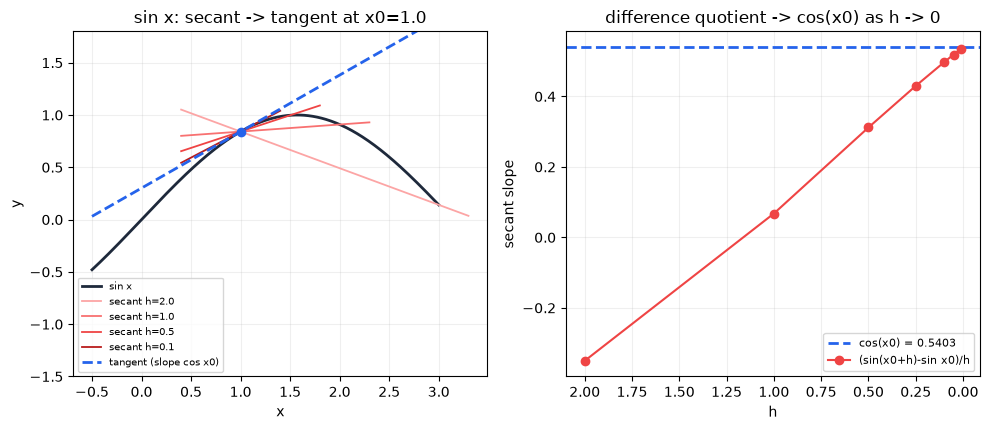

h            secant slope     error vs cos(x0)
 2.000         -0.350175     8.90e-01
 1.000          0.067826     4.72e-01
 0.500          0.312048     2.28e-01
 0.250          0.430055     1.10e-01
 0.100          0.497364     4.29e-02
 0.050          0.519045     2.13e-02
 0.010          0.536086     4.22e-03


In [9]:
x0 = 1.0
hs = np.array([2.0, 1.0, 0.5, 0.25, 0.1, 0.05, 0.01])
secant_slopes = (np.sin(x0 + hs) - np.sin(x0)) / hs
true_slope = np.cos(x0)

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(10, 4.4))

# left: sin curve with shrinking secants converging to the tangent
xx = np.linspace(-0.5, 3.0, 400)
ax1.plot(xx, np.sin(xx), color="#1e293b", lw=2, label="sin x")
for hv, col in zip([2.0, 1.0, 0.5, 0.1], ["#fca5a5", "#f87171", "#ef4444", "#b91c1c"]):
    slope = (np.sin(x0 + hv) - np.sin(x0)) / hv
    xs = np.array([x0 - 0.6, x0 + hv + 0.3])
    ax1.plot(xs, np.sin(x0) + slope * (xs - x0), color=col, lw=1.3,
             label=f"secant h={hv}")
ax1.plot(xx, np.sin(x0) + true_slope * (xx - x0), "--", color="#2563eb", lw=2,
         label="tangent (slope cos x0)")
ax1.plot([x0], [np.sin(x0)], "o", color="#2563eb")
ax1.set_title(f"sin x: secant -> tangent at x0={x0}")
ax1.set_xlabel("x"); ax1.set_ylabel("y")
ax1.set_ylim(-1.5, 1.8); ax1.legend(fontsize=7, loc="lower left"); ax1.grid(alpha=.2)

# right: difference quotient slope -> cos(x0) as h -> 0
ax2.axhline(true_slope, color="#2563eb", ls="--", lw=2,
            label=f"cos(x0) = {true_slope:.4f}")
ax2.plot(hs, secant_slopes, "o-", color="#ef4444", label="(sin(x0+h)-sin x0)/h")
ax2.set_title("difference quotient -> cos(x0) as h -> 0")
ax2.set_xlabel("h"); ax2.set_ylabel("secant slope")
ax2.invert_xaxis(); ax2.legend(fontsize=8); ax2.grid(alpha=.2)

fig.tight_layout()
plt.show()

print("h            secant slope     error vs cos(x0)")
for hv, s in zip(hs, secant_slopes):
    print(f"{hv:6.3f}      {s:12.6f}     {abs(s - true_slope):.2e}")